# Caso DT-011 — AIS/VMS y verificacion del PSMA
## 🔴 Nivel AVANZADO — Detectar apagones AIS y construir un score de riesgo PSMA.

**Curso:** IA Aplicada a la Produccion Pesquera · UTN FRCh · PesquerosEnIA · 2026
**Autor:** Ariel Giamportone — Ingeniero Pesquero, Cientifico de datos e IA, docente-investigador UTN FRTDF, fundador Pesqueros en IA
**Apoya a:** DT-ALGP-2026-011 (adhesion al PSMA / AMERP)

---

> **Frase ancla:** *Lo que no transmite, igual deja rastro. El apagon de AIS es, en si mismo, un dato.*

**Que hace este caso.** El **PSMA** (Port State Measures Agreement) — en castellano **AMERP**, Acuerdo sobre Medidas del Estado Rector del Puerto — permite a un puerto **negar entrada o inspeccionar** a un buque sospechado de pesca ilegal (INDNR). Su aplicacion practica necesita datos: posicion, esfuerzo y trazabilidad de la conducta del buque. Aca reconstruimos ese tablero con datos AIS y mostramos como se construye un **score de riesgo previo al arribo**.

**Numero de ley AMERP en Argentina:** `HUECO` — confirmar en Boletin Oficial antes de publicar. No lo completamos con un valor sin fuente.

**Declaracion de conflicto de interes.** La UTN FRTDF es beneficiaria *prima facie* de la Ley provincial 1545/2024 y de la Ley 1614/2026. Material docente-investigador; no es asesoramiento a ninguna empresa ni a ningun organismo de control.


### Taxonomia de evidencia (invariante de la serie DT-ALGP)

| Clase | Significado |
|---|---|
| `CONFIRMADO` | Verificado en fuente oficial primaria |
| `ESTIMADO` | Calculado a partir de supuestos declarados |
| `REFERENCIAL` | Tomado de fuente secundaria, sujeto a revision |
| `HUECO` | Dato faltante, se marca y no se completa |

> **Sobre los datos de este notebook:** las trayectorias son **sinteticas y verosimiles** (`ESTIMADO`), construidas para ensenar el metodo. Al final se incluye la plantilla para reemplazarlas por datos reales de **Global Fishing Watch** (abiertos). La linea de referencia del borde de la ZEE es **ilustrativa**: *no* es la milla 200 real.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, VERDE, NARANJA = '#08519c', '#a50f15', '#005a32', '#cc6600'
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 11})
np.random.seed(7)

try:
    import folium
    FOLIUM_OK = True
except ImportError:
    FOLIUM_OK = False
    print('folium no instalado -> el mapa interactivo se omite (en Colab: pip install folium)')

print('✓ Entorno listo | folium =', FOLIUM_OK)

✓ Entorno listo | folium = True


In [2]:
# ── Generador de trayectorias AIS sinteticas (formato tipo Global Fishing Watch) ─
# Columnas: mmsi, buque, pabellon, timestamp, lat, lon, speed_kn
USHUAIA = (-54.81, -68.30)
BORDE_ZEE_LON = -62.5   # linea ILUSTRATIVA de referencia (no es la milla 200 real)

def segmento(lat0, lon0, lat1, lon1, n, comportamiento, t0):
    lats = np.linspace(lat0, lat1, n)
    lons = np.linspace(lon0, lon1, n)
    if comportamiento == 'pesca':          # lento y tortuoso
        lats += np.random.normal(0, 0.05, n); lons += np.random.normal(0, 0.05, n)
        spd = np.abs(np.random.normal(3.0, 1.0, n))
    elif comportamiento == 'transito':     # rapido y recto
        spd = np.abs(np.random.normal(10.5, 1.2, n))
    else:                                  # puerto
        spd = np.abs(np.random.normal(0.3, 0.2, n))
    ts = pd.date_range(t0, periods=n, freq='h')
    return pd.DataFrame({'lat': lats, 'lon': lons, 'speed_kn': spd, 'timestamp': ts})

def construir(mmsi, buque, pabellon, tramos, t0):
    partes, t = [], pd.Timestamp(t0)
    for (la0, lo0, la1, lo1, n, comp, salto_h) in tramos:
        seg = segmento(la0, lo0, la1, lo1, n, comp, t)
        partes.append(seg)
        t = seg['timestamp'].iloc[-1] + pd.Timedelta(hours=1 + salto_h)  # salto_h = apagon
    df = pd.concat(partes, ignore_index=True)
    df.insert(0, 'pabellon', pabellon); df.insert(0, 'buque', buque); df.insert(0, 'mmsi', mmsi)
    return df

# Cuatro buques. (la0, lo0, la1, lo1, n_puntos, comportamiento, apagon_horas_despues)
flota = pd.concat([
    # Buque limpio, bandera nacional
    construir(701, 'Austral I', 'ARG', [
        (-54.81,-68.30,-55.00,-66.00, 8,'transito',0),
        (-55.00,-66.00,-55.30,-64.80,10,'pesca',0),
        (-55.30,-64.80,-54.81,-68.30, 8,'transito',0),
    ], '2026-06-01'),
    # Buque nacional con pesca larga, sin apagon
    construir(702, 'Fueguino II', 'ARG', [
        (-54.81,-68.30,-55.40,-65.50, 9,'transito',0),
        (-55.40,-65.50,-55.70,-64.20,14,'pesca',0),
        (-55.70,-64.20,-54.81,-68.30, 9,'transito',0),
    ], '2026-06-01'),
    # Buque pabellon de conveniencia, pesca en el borde y APAGON de 14 h
    construir(703, 'Estrella FOC', 'FOC-1', [
        (-54.81,-68.30,-55.60,-63.50,10,'transito',0),
        (-55.60,-63.50,-55.90,-62.40,10,'pesca',14),   # <- apagon de 14 h aca
        (-55.90,-62.40,-54.81,-68.30,11,'transito',0),
    ], '2026-06-02'),
    # Buque pabellon extranjero, apagon corto (3 h, bajo umbral)
    construir(704, 'Petrel', 'FOC-2', [
        (-54.81,-68.30,-55.20,-64.90,10,'transito',3),
        (-55.20,-64.90,-55.35,-64.30, 6,'pesca',0),
        (-55.35,-64.30,-54.81,-68.30,10,'transito',0),
    ], '2026-06-02'),
], ignore_index=True)

flota.to_csv('/tmp/build/casos_dt/caso_dt11_ais_psma/recursos/ais_flota_sintetica.csv', index=False)
print('Puntos AIS:', len(flota), '| Buques:', flota.mmsi.nunique())
flota.head()

Puntos AIS: 115 | Buques: 4


,mmsi,buque,pabellon,lat,lon,speed_kn,timestamp
0,701,Austral I,ARG,-54.810000,-68.300000,12.528631,2026-06-01 00:00:00
1,701,Austral I,ARG,-54.837143,-67.971429,9.940875,2026-06-01 01:00:00
2,701,Austral I,ARG,-54.864286,-67.642857,10.539384,2026-06-01 02:00:00
3,701,Austral I,ARG,-54.891429,-67.314286,10.989020,2026-06-01 03:00:00
4,701,Austral I,ARG,-54.918571,-66.985714,9.553292,2026-06-01 04:00:00


In [3]:
# ── Regla clasica tipo GFW: velocidad de 1 a 5 nudos ~ pesca ──────────────────
def comportamiento(spd):
    if spd < 1:  return 'puerto'
    if spd <= 5: return 'pesca'
    return 'transito'

flota['comportamiento'] = flota['speed_kn'].apply(comportamiento)
resumen = flota['comportamiento'].value_counts()
print(resumen)
print('\nHoras de pesca detectadas (1 punto = 1 h):', int((flota.comportamiento=='pesca').sum()))

comportamiento
transito    76
pesca       38
puerto       1
Name: count, dtype: int64

Horas de pesca detectadas (1 punto = 1 h): 38


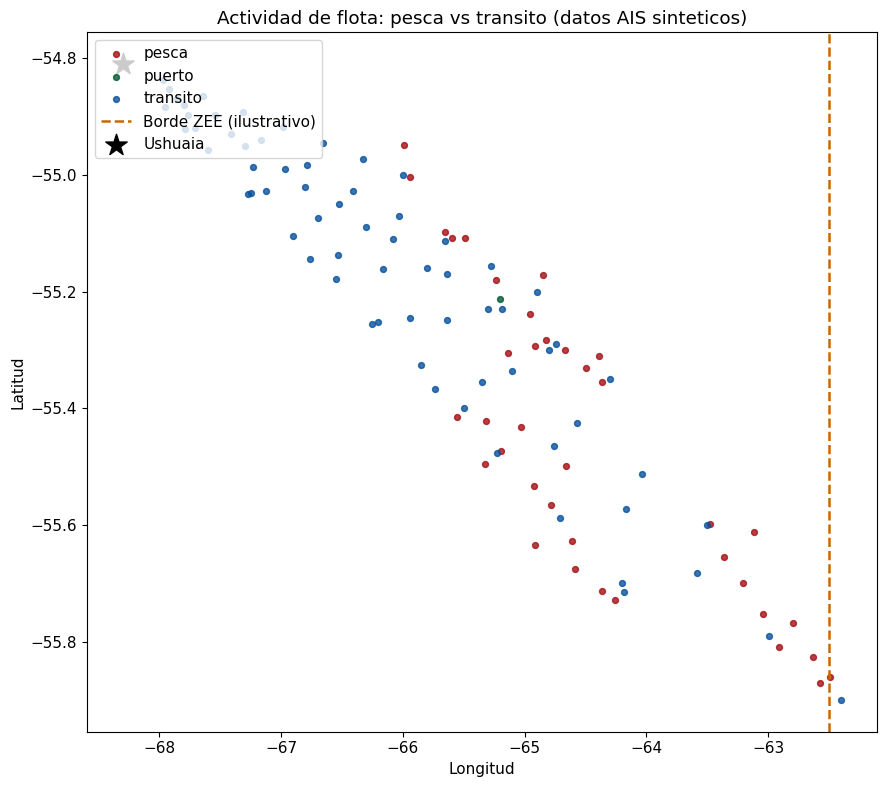

In [4]:
# ── Mapa estatico (siempre funciona, sirve para el PDF de la guia) ───────────
color_comp = {'pesca': ROJO, 'transito': AZUL, 'puerto': VERDE}
fig, ax = plt.subplots(figsize=(9, 8))
for comp, sub in flota.groupby('comportamiento'):
    ax.scatter(sub.lon, sub.lat, s=18, c=color_comp[comp], label=comp, alpha=0.8)
ax.axvline(BORDE_ZEE_LON, color=NARANJA, ls='--', lw=1.8, label='Borde ZEE (ilustrativo)')
ax.scatter(*USHUAIA[::-1], marker='*', s=260, c='black', label='Ushuaia', zorder=5)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Actividad de flota: pesca vs transito (datos AIS sinteticos)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

In [5]:
# ── Mapa interactivo con folium (se ve en Colab / Jupyter) ────────────────────
if FOLIUM_OK:
    import folium
    m = folium.Map(location=[-55.3, -65.5], zoom_start=6, tiles='CartoDB positron')
    folium.Marker(list(USHUAIA), tooltip='Ushuaia', icon=folium.Icon(color='black', icon='anchor', prefix='fa')).add_to(m)
    paleta = {'pesca': 'red', 'transito': 'blue', 'puerto': 'green'}
    for _, r in flota.iterrows():
        folium.CircleMarker([r.lat, r.lon], radius=3,
            color=paleta[r.comportamiento], fill=True, fill_opacity=0.7,
            tooltip=f"{r.buque} ({r.pabellon}) — {r.comportamiento} — {r.speed_kn:.1f} kn").add_to(m)
    m.save('/tmp/build/casos_dt/caso_dt11_ais_psma/recursos/mapa_flota.html')
    print('Mapa guardado en recursos/mapa_flota.html')
    display(m)
else:
    print('folium no disponible; mira el mapa estatico de arriba.')

Mapa guardado en recursos/mapa_flota.html


---
## Esfuerzo pesquero por buque

El **esfuerzo** es el insumo de casi toda evaluacion: horas de pesca, distancia recorrida y proporcion del viaje dedicada a pescar. Lo calculamos por buque.

In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def resumen_buque(g):
    g = g.sort_values('timestamp')
    dist = haversine(g.lat.values[:-1], g.lon.values[:-1], g.lat.values[1:], g.lon.values[1:]).sum()
    horas_pesca = int((g.comportamiento == 'pesca').sum())
    return pd.Series({
        'pabellon': g.pabellon.iloc[0],
        'horas_pesca': horas_pesca,
        'dist_km': round(dist, 1),
        'pct_pesca': round(100*horas_pesca/len(g), 1),
    })

esfuerzo = flota.groupby(['mmsi', 'buque']).apply(resumen_buque, include_groups=False)
esfuerzo.sort_values('horas_pesca', ascending=False)

,,pabellon,horas_pesca,dist_km,pct_pesca
mmsi,buque,,,,
702,Fueguino II,ARG,13,613.1,40.6
703,Estrella FOC,FOC-1,10,807.8,32.3
701,Austral I,ARG,9,483.5,34.6
704,Petrel,FOC-2,6,537.8,23.1


---
## Parte avanzada A — Deteccion de apagones de AIS

Un buque puede **apagar el AIS** para ocultar donde estuvo. El apagon se ve como un salto temporal grande entre dos posiciones consecutivas del mismo buque. Lo detectamos y ubicamos donde ocurrio respecto del borde de la ZEE.

In [7]:
UMBRAL_GAP_H = 6   # horas sin senal para considerar "apagon"

def detectar_apagones(df, umbral_h=UMBRAL_GAP_H):
    filas = []
    for (mmsi, buque), g in df.groupby(['mmsi', 'buque']):
        g = g.sort_values('timestamp').reset_index(drop=True)
        dt_h = g.timestamp.diff().dt.total_seconds() / 3600
        for i in np.where(dt_h > umbral_h)[0]:
            filas.append({
                'mmsi': mmsi, 'buque': buque, 'pabellon': g.pabellon.iloc[0],
                'gap_horas': round(dt_h[i], 1),
                'lat_reaparicion': round(g.lat[i], 3), 'lon_reaparicion': round(g.lon[i], 3),
                'cerca_borde_ZEE': bool(g.lon[i] > BORDE_ZEE_LON - 0.6),
            })
    return pd.DataFrame(filas)

apagones = detectar_apagones(flota)
print('Apagones detectados (umbral', UMBRAL_GAP_H, 'h):')
apagones

Apagones detectados (umbral 6 h):


,mmsi,buque,pabellon,gap_horas,lat_reaparicion,lon_reaparicion,cerca_borde_ZEE
0,703,Estrella FOC,FOC-1,15.0,-55.9,-62.4,True


## Parte avanzada B — Score de riesgo previo al arribo (PSMA / AMERP)

El AMERP no exige "prueba" para inspeccionar: exige **motivo razonable**. Combinamos tres factores en un score 0–100 que ordena a los buques por prioridad de inspeccion. Los pesos son una **decision de politica declarada** (`ESTIMADO`), no una verdad tecnica.

In [8]:
# Riesgo de pabellon: ILUSTRATIVO (no acusa a ningun pais real)
riesgo_pabellon = {'ARG': 0.10, 'FOC-1': 0.80, 'FOC-2': 0.60}
PESOS = {'apagon': 0.45, 'area': 0.35, 'pabellon': 0.20}   # decision de politica (ESTIMADO)

def score_psma(df, apagones, pesos=PESOS):
    tiene_apagon = set(apagones.loc[apagones.gap_horas >= UMBRAL_GAP_H, 'mmsi'])
    filas = []
    for (mmsi, buque), g in df.groupby(['mmsi', 'buque']):
        pesca = g[g.comportamiento == 'pesca']
        f_area = float((pesca.lon > BORDE_ZEE_LON - 0.6).mean()) if len(pesca) else 0.0
        f_gap = 1.0 if mmsi in tiene_apagon else 0.0
        f_flag = riesgo_pabellon.get(g.pabellon.iloc[0], 0.5)
        score = 100 * (pesos['apagon']*f_gap + pesos['area']*f_area + pesos['pabellon']*f_flag)
        filas.append({'buque': buque, 'pabellon': g.pabellon.iloc[0],
                      'apagon': f_gap, 'pesca_borde': round(f_area,2),
                      'riesgo_pabellon': f_flag, 'score_PSMA': round(score,1)})
    return pd.DataFrame(filas).sort_values('score_PSMA', ascending=False).reset_index(drop=True)

ranking = score_psma(flota, apagones)
ranking

,buque,pabellon,apagon,pesca_borde,riesgo_pabellon,score_PSMA
0,Estrella FOC,FOC-1,1.0,0.6,0.8,82.0
1,Petrel,FOC-2,0.0,0.0,0.6,12.0
2,Fueguino II,ARG,0.0,0.0,0.1,2.0
3,Austral I,ARG,0.0,0.0,0.1,2.0


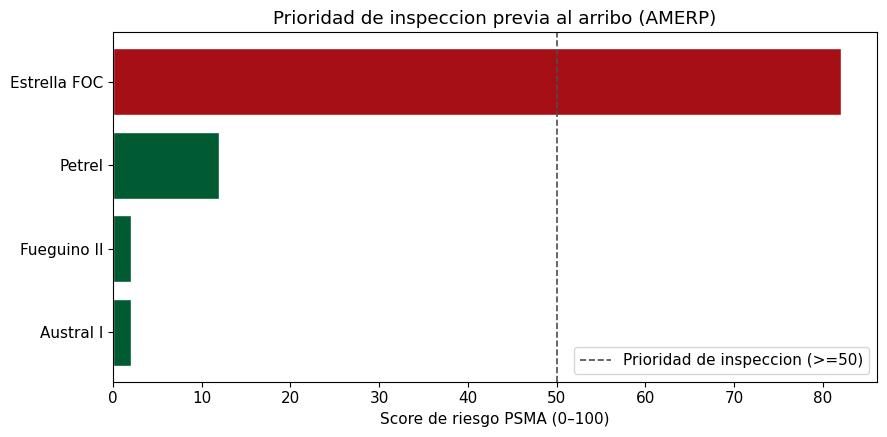

Candidato principal a inspeccion / posible denegacion de entrada: Estrella FOC (FOC-1), score 82.0.


In [9]:
# Visualizacion del ranking
fig, ax = plt.subplots(figsize=(9,4.5))
colores = [ROJO if s >= 50 else NARANJA if s >= 25 else VERDE for s in ranking.score_PSMA]
ax.barh(ranking.buque[::-1], ranking.score_PSMA[::-1], color=colores[::-1], edgecolor='white')
ax.axvline(50, color='0.3', ls='--', lw=1.2, label='Prioridad de inspeccion (>=50)')
ax.set_xlabel('Score de riesgo PSMA (0–100)')
ax.set_title('Prioridad de inspeccion previa al arribo (AMERP)')
ax.legend(); plt.tight_layout(); plt.show()

top = ranking.iloc[0]
print(f'Candidato principal a inspeccion / posible denegacion de entrada: {top.buque} '
      f'({top.pabellon}), score {top.score_PSMA}.')

### Sensibilidad y desafio

- **Sensibilidad.** Cambia los `PESOS` (por ejemplo, dale mas peso al pabellon). ¿El buque top se mantiene? Un score robusto no deberia cambiar de lider ante ajustes menores.
- **Desafio.** Baja `UMBRAL_GAP_H` a 2 horas. ¿Cuantos buques quedan marcados por apagon? Discutí el costo de los **falsos positivos**: inspeccionar de mas tiene costo operativo y diplomatico; inspeccionar de menos deja pasar INDNR. Ese equilibrio es exactamente el tipo de decision que el AMERP delega en el Estado rector del puerto — y que un buen tablero de datos vuelve explicita en vez de discrecional.

---
## Apendice — Conectar con datos reales (Global Fishing Watch)

Para reemplazar los datos sinteticos por datos reales, pedi un token gratuito en la [Global Fishing Watch API](https://globalfishingwatch.org/our-apis/) y adapta esta plantilla (correr en Colab, **no** ejecutada aca):

```python
import requests
TOKEN = "TU_TOKEN_GFW"   # HUECO: reemplazar por tu token
headers = {"Authorization": f"Bearer {TOKEN}"}

# Consulta de eventos de pesca en un area y periodo (revisar la version vigente de la API en la doc)
url = "https://gateway.api.globalfishingwatch.org/v3/events"
params = {
    "datasets[0]": "public-global-fishing-events:latest",
    "start-date": "2026-06-01",
    "end-date":   "2026-06-30",
    # bounding box aproximado del Mar Argentino sur (ajustar):
    "bbox": "-68,-56,-62,-54",
}
r = requests.get(url, headers=headers, params=params, timeout=60)
r.raise_for_status()
eventos = r.json()
# ... normalizar a las columnas mmsi/lat/lon/timestamp/speed y correr el mismo pipeline
```

> Los nombres exactos de datasets y parametros cambian entre versiones de la API: verifica siempre la documentacion oficial vigente. Todo lo demas de este notebook (deteccion de apagones, esfuerzo, score PSMA) funciona igual sobre datos reales.

---
## Sintesis

Con datos de posicion y tres reglas simples — velocidad, salto temporal y ubicacion — pasamos de "hay que aplicar el PSMA" a un **tablero operativo** que ordena buques por prioridad de inspeccion. El apagon de AIS, lejos de borrar informacion, la genera: la ausencia de senal en el lugar equivocado es evidencia. Ese es el aporte concreto de la ciencia de datos al DT-011: convertir un compromiso internacional en una decision trazable del Estado rector del puerto.

**Transferible.** El mismo pipeline (esfuerzo + apagones + score) sirve para VMS, para control de areas cerradas y para auditar el cumplimiento de vedas.

---
### Que NO afirma este notebook

1. No afirma que ningun buque real haya cometido pesca INDNR: los datos son sinteticos.
2. No afirma que un apagon de AIS pruebe ilegalidad: es un **indicio** que habilita inspeccion, no una condena.
3. No usa la posicion real de la milla 200: la frontera es una linea ilustrativa de referencia.
4. No sustituye el marco legal: la decision de negar entrada o inspeccionar corresponde a la autoridad competente bajo el AMERP.

**Fuentes para cerrar huecos:** numero de ley AMERP (Boletin Oficial) y datos AIS reales (Global Fishing Watch API).